In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

In [60]:
data = pd.read_csv("mobilbekas_jakarta.csv")


In [61]:
kolom = ["Merk", "Model", "Tahun Produksi", "Jarak Tempuh", "Warna", "Engine CC", "Transmission", "Seat Capacity", "Harga", "Fuel Type"]
df = pd.DataFrame(data[kolom])
df.head()

,Merk,Model,Tahun Produksi,Jarak Tempuh,Warna,Engine CC,Transmission,Seat Capacity,Harga,Fuel Type
0,Bentley,Continental Gt Speed,"2,010.00","7,500.00",Black,"5,998.00",Automatic,4.00,"1,675,000,000.00",Petrol
1,Aston,Martin Virage,"2,012.00","2,500.00",Black,"5,935.00",Automatic,2.00,"2,750,000,000.00",Petrol
2,Audi,Q7 Tfsi Quattro,"2,015.00","37,500.00",Black,"2,995.00",Automatic,7.00,"565,000,000.00",Petrol
3,Honda,Cr V Turbo Prestige,"2,019.00","82,500.00",Grey,"1,498.00",Automatic,5.00,"335,000,000.00",Petrol
4,Bmw,330I M Sport,"2,016.00","37,500.00",Blue,"1,998.00",Automatic,5.00,"550,000,000.00",Petrol


In [62]:
print(df.isnull().sum()) # Cek null atau tidak
print(df.duplicated().sum()) # Cek duplikat atau tidak

Merk                5
Model               5
Tahun Produksi    314
Jarak Tempuh      314
Warna             314
Engine CC         554
Transmission      314
Seat Capacity     314
Harga             337
Fuel Type         319
dtype: int64
1936


In [63]:
# 2. Langkah-Langkah Perhitungan Persentase Missing Value

# a. Hitung jumlah total nilai hilang (NaN) per kolom
missing_count = df.isnull().sum()

# b. Hitung jumlah total baris dalam DataFrame (untuk penyebut)
total_rows = len(df) # atau df.shape[0]

# c. Hitung persentase nilai hilang per kolom
# Rumus: (Jumlah Missing / Total Baris) * 100
missing_percentage = (missing_count / total_rows) * 100

# 3. Gabungkan dan Tampilkan Hasil
# Membuat DataFrame baru untuk laporan missing value
missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Total Rows': total_rows,
    'Missing Percentage (%)': missing_percentage.round(2)
})

# Filter hanya kolom yang memiliki missing value > 0
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values(
    by='Missing Percentage (%)', ascending=False
)

print("\n--- Laporan Persentase Missing Value ---")

if missing_report.empty:
    print("Tidak ditemukan missing value dalam data.")
else:
    print(missing_report)
    
# Contoh interpretasi:
# - Kolom cc, bahan_bakar, dan Jarak_km memiliki missing value 20%.
# - Karena persentase missing value rendah (20% atau 1 baris dari 5), 
#   kita dapat mempertimbangkan imputasi (mengisi dengan mean/median) 
#   atau menghapus baris tersebut jika total data kita sangat banyak.



--- Laporan Persentase Missing Value ---
                Missing Count  Total Rows  Missing Percentage (%)
Engine CC                 554       12796                    4.33
Harga                     337       12796                    2.63
Fuel Type                 319       12796                    2.49
Jarak Tempuh              314       12796                    2.45
Warna                     314       12796                    2.45
Tahun Produksi            314       12796                    2.45
Seat Capacity             314       12796                    2.45
Transmission              314       12796                    2.45
Model                       5       12796                    0.04
Merk                        5       12796                    0.04


In [64]:
# Pilih hanya kolom numerik
kolom_numerik = df.select_dtypes(include=["number"]).columns
total_rows = len(df)
outlier_report = {}

print(f"Total baris data: {total_rows}")
print(f"Kolom Numerik yang dianalisis: {list(kolom_numerik)}")
print("-" * 50)


# Iterasi melalui setiap kolom numerik
for col in kolom_numerik:
    # Hanya hitung pada nilai yang valid (bukan NaN)
    data_col = df[col].dropna() 
    
    if len(data_col) < 2:
        # Lewati jika kolom memiliki kurang dari 2 data valid
        outlier_report[col] = {"Count": 0, "Percentage": 0.0, "Note": "Data tidak cukup"}
        continue

    # 1. Hitung Q1, Q3, dan IQR
    Q1 = data_col.quantile(0.25)
    Q3 = data_col.quantile(0.75)
    IQR = Q3 - Q1

    # 2. Hitung Batas Bawah dan Batas Atas IQR
    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    # 3. Identifikasi Outlier
    # Hitung jumlah baris yang berada di luar batas
    outlier_count = len(df[(df[col] < batas_bawah) | (df[col] > batas_atas)])
    
    # 4. Hitung Persentase
    outlier_percentage = (outlier_count / total_rows) * 100

    outlier_report[col] = {
        "Count": outlier_count,
        "Percentage": f"{outlier_percentage:.2f}%",
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas
    }

# Konversi laporan menjadi DataFrame agar mudah dibaca
outlier_df = pd.DataFrame.from_dict(outlier_report, orient='index')
outlier_df.index.name = "Variabel"

print("📊 Laporan Outlier per Variabel (Metode IQR)")
print("----------------------------------------")
print(outlier_df.sort_values(by='Count', ascending=False))

# INSIGHT: Variabel 'harga' dan 'Jarak_km' seringkali memiliki outlier karena keberadaan mobil mewah atau mobil bekas pakai yang ekstrem.


Total baris data: 12796
Kolom Numerik yang dianalisis: ['Tahun Produksi', 'Jarak Tempuh', 'Engine CC', 'Seat Capacity', 'Harga']
--------------------------------------------------
📊 Laporan Outlier per Variabel (Metode IQR)
----------------------------------------
                Count Percentage     Batas Bawah       Batas Atas
Variabel                                                         
Harga            1171      9.15% -462,000,000.00 1,282,000,000.00
Engine CC         400      3.13%           10.50         3,974.50
Jarak Tempuh      274      2.14%      -57,500.00       142,500.00
Tahun Produksi    180      1.41%        2,007.00         2,031.00
Seat Capacity      30      0.23%            2.00            10.00


Kolom numerik: ['Tahun Produksi', 'Jarak Tempuh', 'Engine CC', 'Seat Capacity', 'Harga']


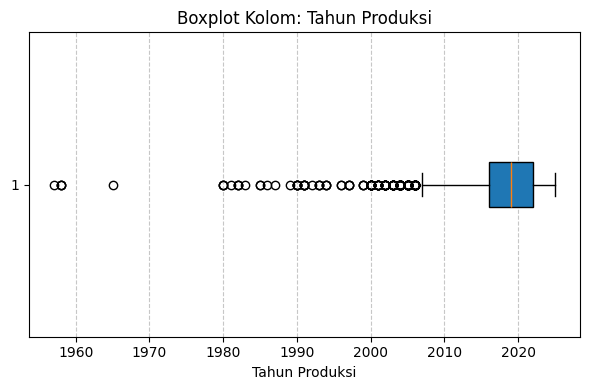

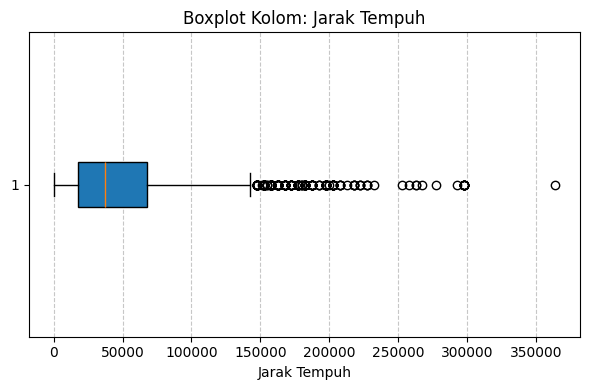

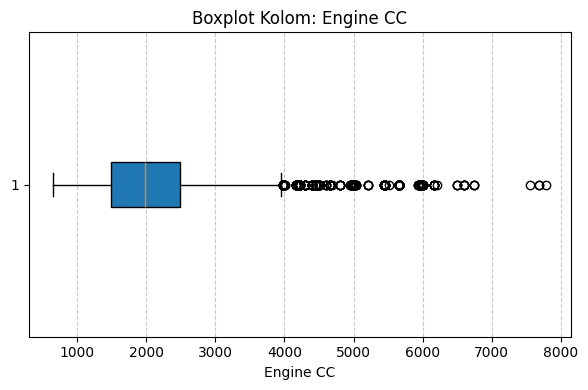

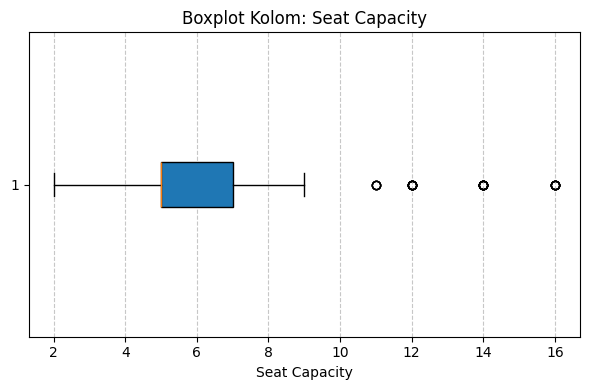

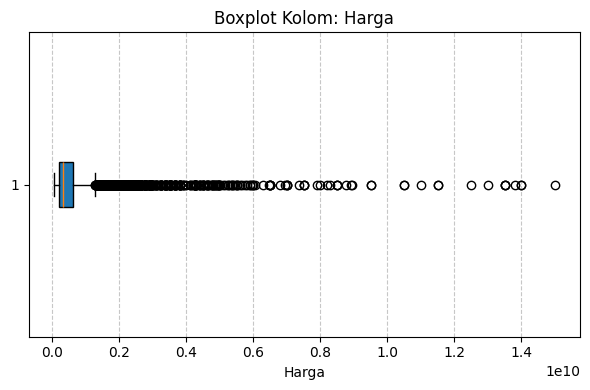

In [65]:
kolom_numerik = df.select_dtypes(include=["number"]).columns
print("Kolom numerik:", list(kolom_numerik))

for kolom in kolom_numerik:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[kolom].dropna(), vert=False, patch_artist=True)
    plt.title(f"Boxplot Kolom: {kolom}")
    plt.xlabel(kolom)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [66]:
print(df.duplicated().sum()) # Cek data yang duplicate

1936


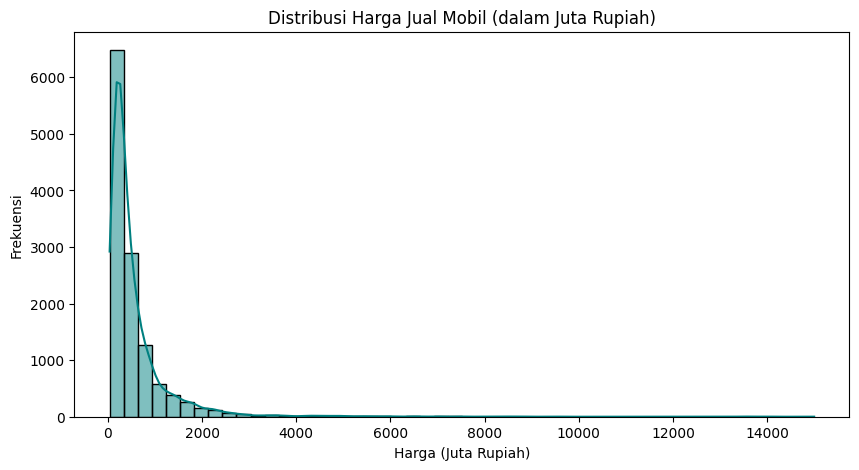

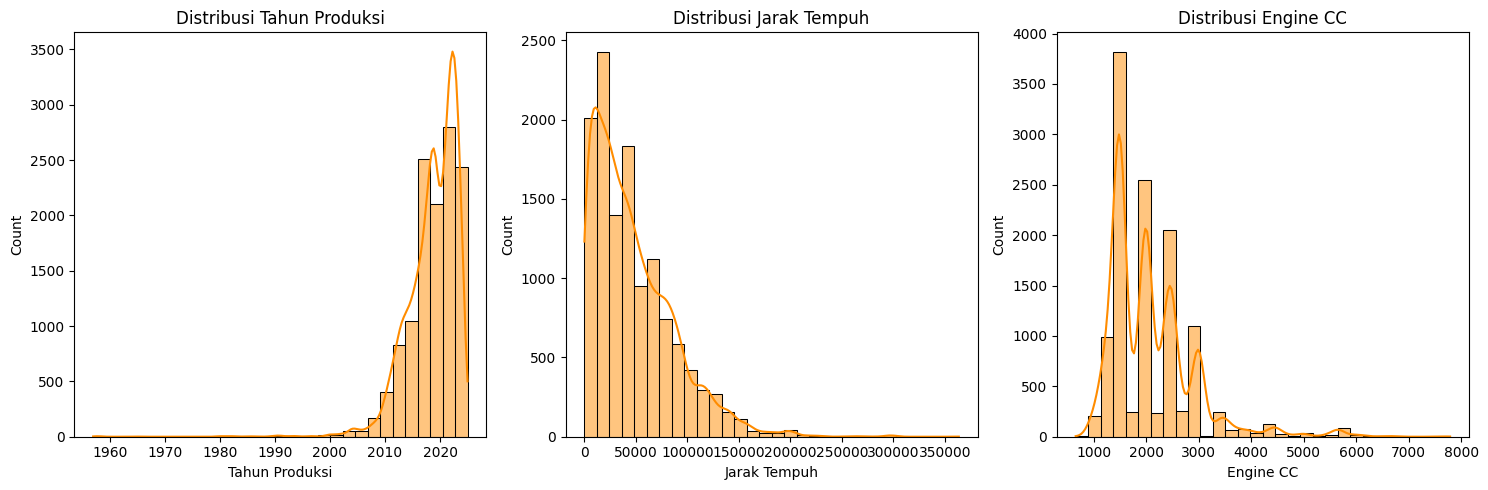

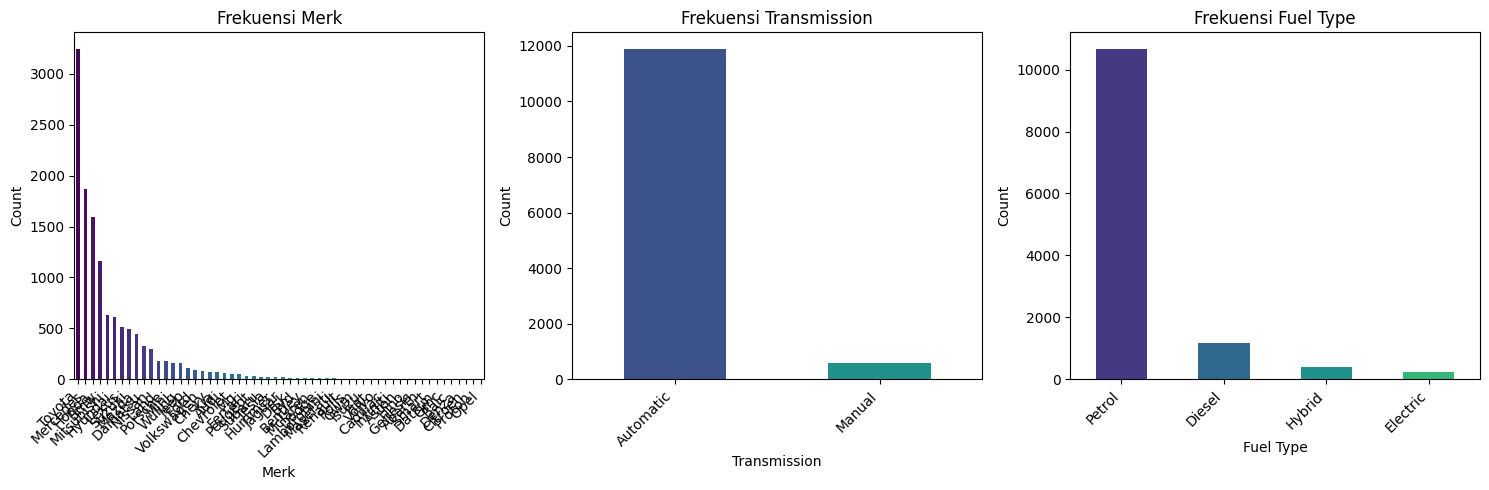

--------------------------------------------------


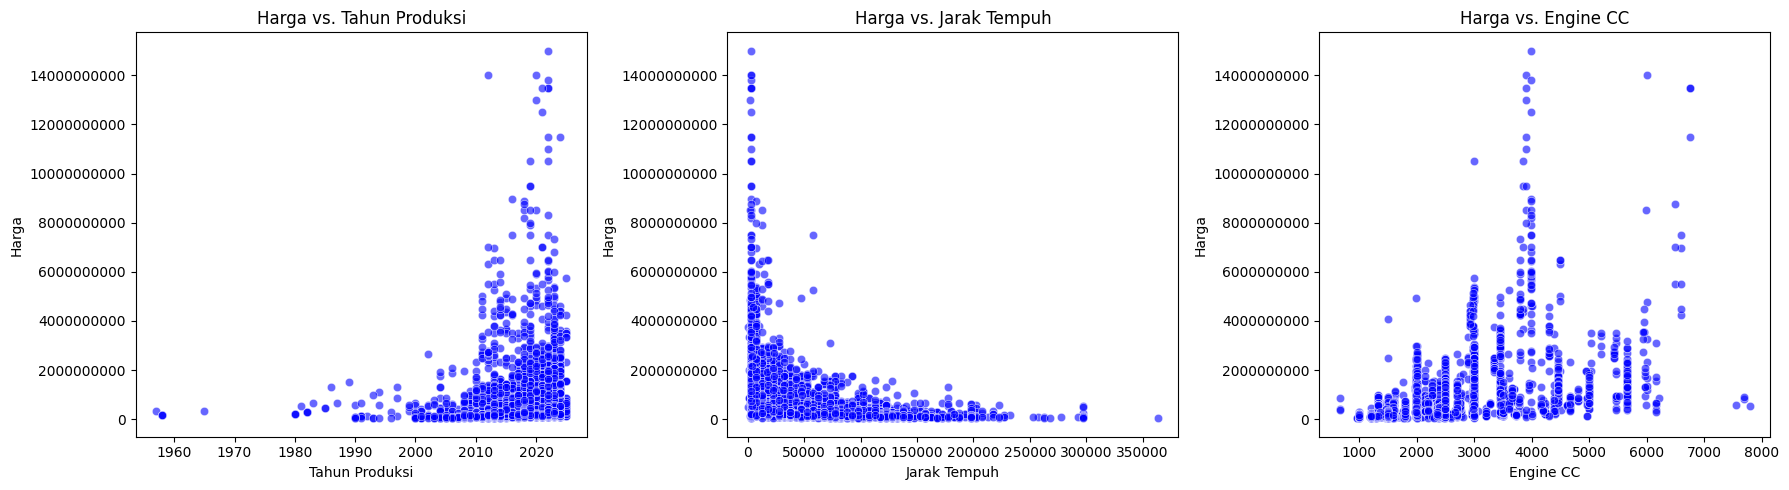

C:\Users\HP\AppData\Local\Temp\ipykernel_7188\3420946608.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Harga', data=df, ax=axes[i], palette=palettes[i % len(palettes)])
C:\Users\HP\AppData\Local\Temp\ipykernel_7188\3420946608.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
C:\Users\HP\AppData\Local\Temp\ipykernel_7188\3420946608.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=col, y='Harga', data=df, ax=axes[i], palette=palettes[i % len(palettes)])
C:\Users\HP\AppData\Local\Temp\ipykernel_7188\3420946608

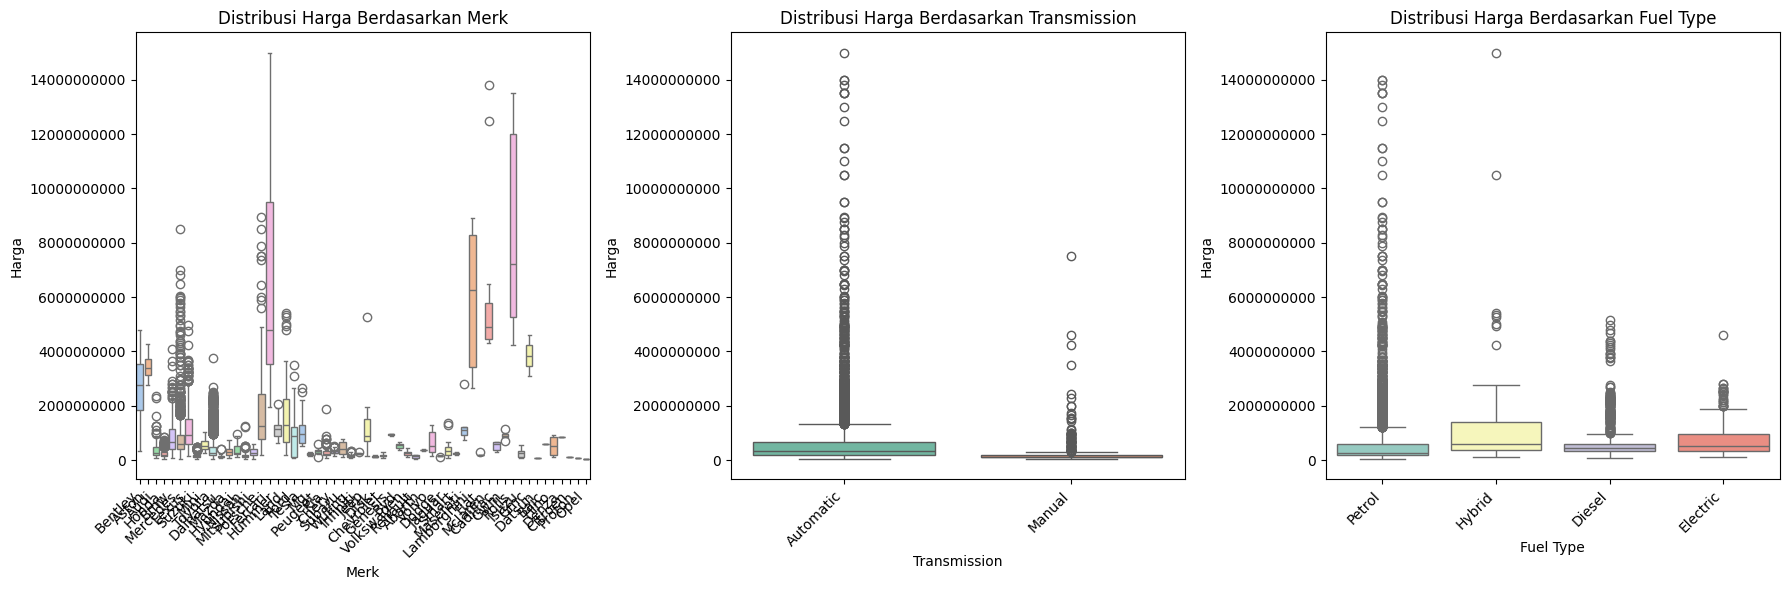


5.3. Matriks Korelasi Numerik:
Harga             1.00
Engine CC         0.54
Tahun Produksi    0.13
Seat Capacity    -0.21
Jarak Tempuh     -0.35
Name: Harga, dtype: float64


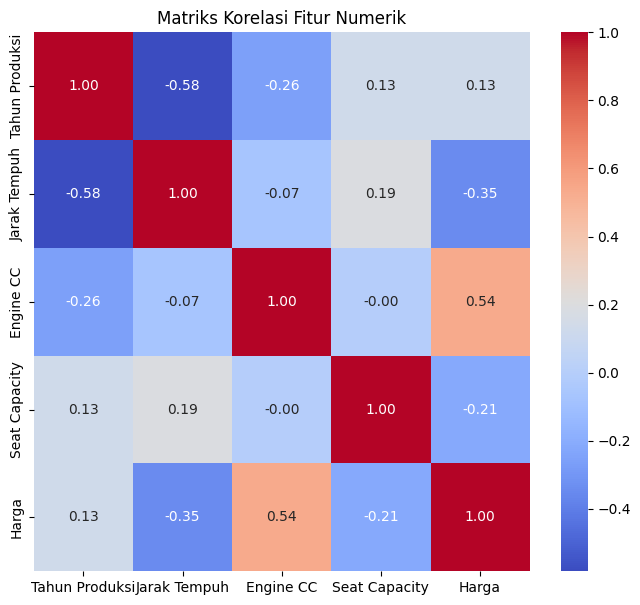

In [67]:
# --- 4. ANALISIS UNIVARIATE (DISTRIBUSI) ---

# 4.1. Distribusi Variabel Target (Harga)
# Gunakan try-except karena variabel mungkin belum tentu ada di data aktual
try:
    plt.figure(figsize=(10, 5))
    sns.histplot(df['Harga'] / 1_000_000, bins=50, kde=True, color='teal')
    plt.title('Distribusi Harga Jual Mobil (dalam Juta Rupiah)')
    plt.xlabel('Harga (Juta Rupiah)')
    plt.ylabel('Frekuensi')
    plt.ticklabel_format(style='plain', axis='x')
    plt.show()
except KeyError:
    print("WARNING: Kolom 'Harga' tidak ditemukan untuk plot distribusi target.")

# 4.2. Distribusi Variabel Numerik Kunci
# Asumsi kolom numerik kunci yang Anda miliki
numerical_cols = ['Tahun Produksi', 'Jarak Tempuh', 'Engine CC'] 
valid_num_cols = [col for col in numerical_cols if col in df.columns]

if valid_num_cols:
    plt.figure(figsize=(5 * len(valid_num_cols), 5))
    for i, col in enumerate(valid_num_cols):
        plt.subplot(1, len(valid_num_cols), i + 1)
        sns.histplot(df[col], bins=30, kde=True, color='darkorange')
        plt.title(f'Distribusi {col}')
        plt.xlabel(col)
    plt.tight_layout()
    plt.show()
else:
    print("WARNING: Tidak ada kolom numerik kunci ('Tahun Produksi', 'Jarak Tempuh', 'Engine CC') untuk diplot.")


# 4.3. Distribusi Variabel Kategorikal
# Asumsi kolom kategorikal yang Anda miliki
categorical_cols = ['Merk', 'Transmission', 'Fuel Type']
valid_cat_cols = [col for col in categorical_cols if col in df.columns]

if valid_cat_cols:
    plt.figure(figsize=(5 * len(valid_cat_cols), 5))
    for i, col in enumerate(valid_cat_cols):
        plt.subplot(1, len(valid_cat_cols), i + 1)
        # Gunakan value_counts dan plot bar
        df[col].value_counts().plot(kind='bar', color=sns.color_palette("viridis", len(df[col].unique())))
        plt.title(f'Frekuensi {col}')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Count')
    plt.tight_layout()
    plt.show()
else:
    print("WARNING: Tidak ada kolom kategorikal kunci ('Merk', 'Transmission', 'Fuel Type') untuk diplot.")

print("-" * 50)


# --- 5. ANALISIS BIVARIATE (HUBUNGAN DENGAN Harga) ---
if 'Harga' in df.columns:
    # 5.1. Harga vs. Variabel Numerik
    num_plot_cols = [col for col in ['Tahun Produksi', 'Jarak Tempuh', 'Engine CC'] if col in df.columns]
    
    if num_plot_cols:
        fig, axes = plt.subplots(1, len(num_plot_cols), figsize=(6 * len(num_plot_cols), 5))
        if len(num_plot_cols) == 1: # Handle case with only one subplot
            axes = [axes]

        for i, col in enumerate(num_plot_cols):
            sns.scatterplot(x=col, y='Harga', data=df, ax=axes[i], alpha=0.6, color='blue')
            axes[i].set_title(f'Harga vs. {col}')
            axes[i].ticklabel_format(style='plain', axis='y')

        plt.tight_layout()
        plt.show()
    
    # 5.2. Harga vs. Variabel Kategorikal (Box Plot)
    cat_plot_cols = [col for col in ['Merk', 'Transmission', 'Fuel Type'] if col in df.columns]
    
    if cat_plot_cols:
        fig, axes = plt.subplots(1, len(cat_plot_cols), figsize=(6 * len(cat_plot_cols), 6))
        if len(cat_plot_cols) == 1: # Handle case with only one subplot
            axes = [axes]
            
        palettes = ['pastel', 'Set2', 'Set3'] # Cycle through palettes

        for i, col in enumerate(cat_plot_cols):
            sns.boxplot(x=col, y='Harga', data=df, ax=axes[i], palette=palettes[i % len(palettes)])
            axes[i].set_title(f'Distribusi Harga Berdasarkan {col}')
            axes[i].ticklabel_format(style='plain', axis='y')
            axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

        plt.tight_layout()
        plt.show()

    # 5.3. Matriks Korelasi (Hanya untuk fitur numerik)
    numerical_df = df.select_dtypes(include=np.number).dropna()

    if not numerical_df.empty:
        print("\n5.3. Matriks Korelasi Numerik:")
        correlation_matrix = numerical_df.corr()
        # Korelasi dengan Target Harga
        if 'Harga' in correlation_matrix.columns:
            print(correlation_matrix['Harga'].sort_values(ascending=False)) 

            plt.figure(figsize=(8, 7))
            sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
            plt.title('Matriks Korelasi Fitur Numerik')
            plt.show()
        else:
            print("WARNING: Kolom 'Harga' tidak ditemukan dalam matriks korelasi.")
    else:
        print("WARNING: Tidak ada data numerik yang valid untuk Matriks Korelasi.")
        
else:
    print("SKIPPING: Bagian Bivariate Analysis dilewati karena kolom 'Harga' tidak ditemukan.")
# Insight: Cari korelasi terkuat dengan 'Harga' (misalnya, Tahun Produksi, Engine CC, Jarak Tempuh).


# Data Preparation

In [68]:
df.dropna(inplace=True)
print(df.isnull().sum()) # Cek null atau tidak
df.drop_duplicates(inplace=True)
print(df.duplicated().sum()) # Cek duplikat atau tidak

Merk              0
Model             0
Tahun Produksi    0
Jarak Tempuh      0
Warna             0
Engine CC         0
Transmission      0
Seat Capacity     0
Harga             0
Fuel Type         0
dtype: int64
0


In [69]:
def apply_iqr_capping(df, column):
    """
    Menerapkan Capping (Winsorization) berbasis IQR ke kolom tertentu.
    Outlier di luar Q1 - 1.5*IQR dan Q3 + 1.5*IQR akan diganti dengan batas tersebut.
    """
    print(f"\n--- Menerapkan Capping untuk kolom: '{column}' ---")

    # 1. Hitung Q1, Q3, dan IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # 2. Tentukan Batas Atas dan Bawah (1.5 * IQR)
    batas_atas = Q3 + 1.5 * IQR
    batas_bawah = Q1 - 1.5 * IQR
    
    print(f"IQR (Interquartile Range): {IQR:.2f}")
    print(f"Batas Atas (Upper Bound): {batas_atas:.2f}")
    print(f"Batas Bawah (Lower Bound): {batas_bawah:.2f}")
    
    # 3. Terapkan Capping
    new_column_name = f'{column}_capped'
    df[new_column_name] = np.where(
        df[column] > batas_atas,
        batas_atas,
        np.where(
            df[column] < batas_bawah,
            batas_bawah,
            df[column] # Pertahankan nilai normal
        )
    )
    
    # 4. Verifikasi dan Informasi
    outliers_atas = len(df[df[column] > batas_atas])
    outliers_bawah = len(df[df[column] < batas_bawah])
    print(f"Jumlah outlier di atas batas: {outliers_atas}")
    print(f"Jumlah outlier di bawah batas: {outliers_bawah}")
    print(f"Kolom baru '{new_column_name}' sudah dibuat.")
    
    return df

# --- Panggilan Fungsi Capping (Bagian ini sudah benar) ---
# Pastikan Anda telah mengimpor data/membuat df di bagian atas skrip Anda
# df = pd.DataFrame(data_anda)

df = apply_iqr_capping(df, 'Harga')
df = apply_iqr_capping(df, 'Jarak Tempuh')
df = apply_iqr_capping(df, 'Engine CC')
df = apply_iqr_capping(df, 'Tahun Produksi')
df = apply_iqr_capping(df, 'Seat Capacity')

# --- Tampilkan perbandingan hasil (Contoh 6 baris pertama) ---
print("\n--- Perbandingan Data Asli vs Data Setelah Capping ---")
kolom_tampil = ['Tahun Produksi_capped', 'Harga_capped', 'Engine CC_capped', 'Jarak Tempuh_capped', "Seat Capacity_capped"]
print(df[kolom_tampil].head())


--- Menerapkan Capping untuk kolom: 'Harga' ---
IQR (Interquartile Range): 461000000.00
Batas Atas (Upper Bound): 1350500000.00
Batas Bawah (Lower Bound): -493500000.00
Jumlah outlier di atas batas: 914
Jumlah outlier di bawah batas: 0
Kolom baru 'Harga_capped' sudah dibuat.

--- Menerapkan Capping untuk kolom: 'Jarak Tempuh' ---
IQR (Interquartile Range): 50000.00
Batas Atas (Upper Bound): 142500.00
Batas Bawah (Lower Bound): -57500.00
Jumlah outlier di atas batas: 253
Jumlah outlier di bawah batas: 0
Kolom baru 'Jarak Tempuh_capped' sudah dibuat.

--- Menerapkan Capping untuk kolom: 'Engine CC' ---
IQR (Interquartile Range): 990.00
Batas Atas (Upper Bound): 3973.00
Batas Bawah (Lower Bound): 13.00
Jumlah outlier di atas batas: 379
Jumlah outlier di bawah batas: 0
Kolom baru 'Engine CC_capped' sudah dibuat.

--- Menerapkan Capping untuk kolom: 'Tahun Produksi' ---
IQR (Interquartile Range): 6.00
Batas Atas (Upper Bound): 2031.00
Batas Bawah (Lower Bound): 2007.00
Jumlah outlier di at


Kolom numerik untuk Boxplot: ['Harga_capped', 'Jarak Tempuh_capped', 'Engine CC_capped', 'Tahun Produksi_capped', 'Seat Capacity_capped']


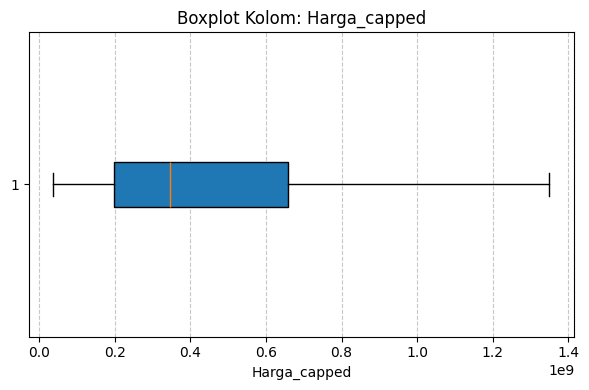

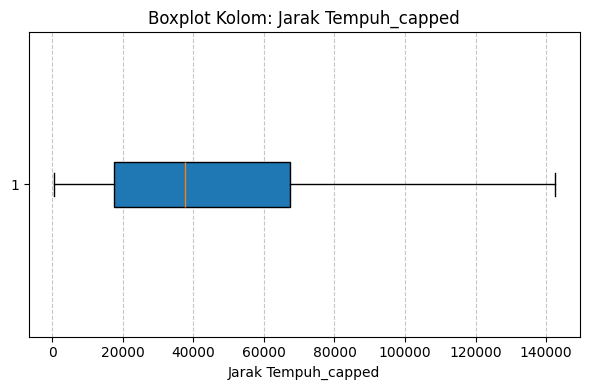

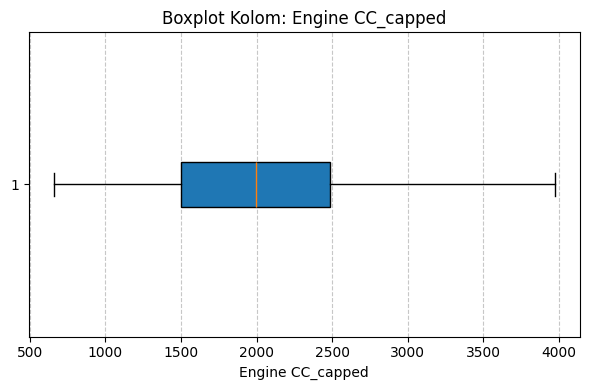

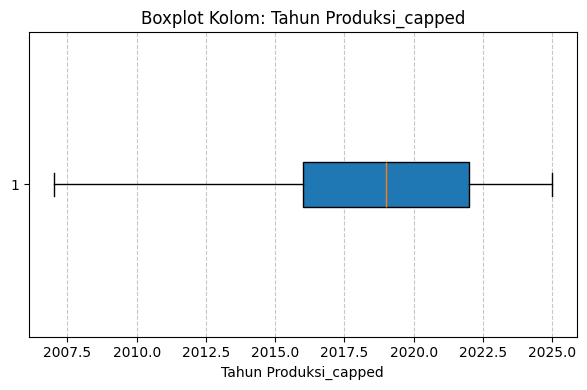

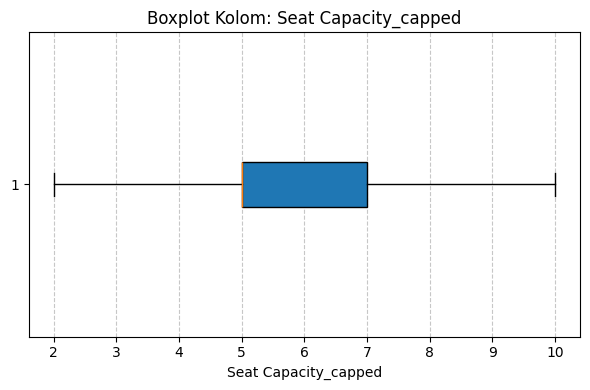

In [70]:
# 1. Betulkan cara mendefinisikan list kolom (INI SUMBER ERRORNYA)
kolom_numerik = [
    "Harga_capped", 
    "Jarak Tempuh_capped", 
    "Engine CC_capped", 
    "Tahun Produksi_capped", 
    "Seat Capacity_capped"
]
print("\nKolom numerik untuk Boxplot:", kolom_numerik) 

# 2. Iterasi dan plot boxplot
for kolom in kolom_numerik:
    plt.figure(figsize=(6, 4))
    
    # Pastikan kolom yang diakses ada di DataFrame Anda
    if kolom in df.columns:
        # Gunakan .dropna() hanya jika ada nilai NaN
        plt.boxplot(df[kolom].dropna(), vert=False, patch_artist=True)
        plt.title(f"Boxplot Kolom: {kolom}")
        plt.xlabel(kolom)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        # Pesan error yang lebih informatif jika ada kesalahan
        print(f"ERROR: Kolom '{kolom}' tidak ditemukan di DataFrame. Cek nama kolom Anda.")

In [71]:
print(f"{df["Fuel Type"].unique()}")
print(f"{df["Transmission"].unique()}")
print(f"{df["Merk"].unique()}")
print(f"{df["Model"].unique()}")

['Petrol' 'Hybrid' 'Diesel']
['Automatic' 'Manual']
['Bentley' 'Aston' 'Audi' 'Honda' 'Bmw' 'Mercedes' 'Lexus' 'Suzuki' 'Mini'
 'Toyota' 'Daihatsu' 'Mazda' 'Hyundai' 'Nissan' 'Mitsubishi' 'Porsche'
 'Ferrari' 'Hummer' 'Land' 'Ford' 'Mg' 'Peugeot' 'Kia' 'Subaru' 'Chery'
 'Wuling' 'Infiniti' 'Jeep' 'Dfsk' 'Chevrolet' 'Volkswagen' 'Renault'
 'Abarth' 'Volvo' 'Dodge' 'Jaguar' 'Smart' 'Maserati' 'Lamborghini' 'Fiat'
 'Mclaren' 'Cadillac' 'Gwm' 'Rolls' 'Isuzu' 'Gmc' 'Datsun' 'Baic' 'Hino'
 'Citroen' 'Proton' 'Opel']
['Continental Gt Speed' 'Martin Virage' 'Q7 Tfsi Quattro' ...
 'Yaris Cross G' 'Ranger Wildtrak Dual Cab' 'Scenic Grand']


## Feature Engineering

In [72]:
# Asumsikan tahun saat ini adalah 2025
TAHUN_SAAT_INI = 2025
df['Umur Mobil'] = TAHUN_SAAT_INI - df['Tahun Produksi']
# Setelah ini, kolom 'Tahun Produksi' dapat dipertimbangkan untuk dihapus
df.head()

,Merk,Model,Tahun Produksi,Jarak Tempuh,Warna,Engine CC,Transmission,Seat Capacity,Harga,Fuel Type,Harga_capped,Jarak Tempuh_capped,Engine CC_capped,Tahun Produksi_capped,Seat Capacity_capped,Umur Mobil
0,Bentley,Continental Gt Speed,"2,010.00","7,500.00",Black,"5,998.00",Automatic,4.00,"1,675,000,000.00",Petrol,"1,350,500,000.00","7,500.00","3,973.00","2,010.00",4.00,15.00
1,Aston,Martin Virage,"2,012.00","2,500.00",Black,"5,935.00",Automatic,2.00,"2,750,000,000.00",Petrol,"1,350,500,000.00","2,500.00","3,973.00","2,012.00",2.00,13.00
2,Audi,Q7 Tfsi Quattro,"2,015.00","37,500.00",Black,"2,995.00",Automatic,7.00,"565,000,000.00",Petrol,"565,000,000.00","37,500.00","2,995.00","2,015.00",7.00,10.00
3,Honda,Cr V Turbo Prestige,"2,019.00","82,500.00",Grey,"1,498.00",Automatic,5.00,"335,000,000.00",Petrol,"335,000,000.00","82,500.00","1,498.00","2,019.00",5.00,6.00
4,Bmw,330I M Sport,"2,016.00","37,500.00",Blue,"1,998.00",Automatic,5.00,"550,000,000.00",Petrol,"550,000,000.00","37,500.00","1,998.00","2,016.00",5.00,9.00


## Encoding

In [73]:
df['Model'] = df['Model'].str.split().str[0]  # ambil kata pertama saja

In [74]:
df.head()

,Merk,Model,Tahun Produksi,Jarak Tempuh,Warna,Engine CC,Transmission,Seat Capacity,Harga,Fuel Type,Harga_capped,Jarak Tempuh_capped,Engine CC_capped,Tahun Produksi_capped,Seat Capacity_capped,Umur Mobil
0,Bentley,Continental,"2,010.00","7,500.00",Black,"5,998.00",Automatic,4.00,"1,675,000,000.00",Petrol,"1,350,500,000.00","7,500.00","3,973.00","2,010.00",4.00,15.00
1,Aston,Martin,"2,012.00","2,500.00",Black,"5,935.00",Automatic,2.00,"2,750,000,000.00",Petrol,"1,350,500,000.00","2,500.00","3,973.00","2,012.00",2.00,13.00
2,Audi,Q7,"2,015.00","37,500.00",Black,"2,995.00",Automatic,7.00,"565,000,000.00",Petrol,"565,000,000.00","37,500.00","2,995.00","2,015.00",7.00,10.00
3,Honda,Cr,"2,019.00","82,500.00",Grey,"1,498.00",Automatic,5.00,"335,000,000.00",Petrol,"335,000,000.00","82,500.00","1,498.00","2,019.00",5.00,6.00
4,Bmw,330I,"2,016.00","37,500.00",Blue,"1,998.00",Automatic,5.00,"550,000,000.00",Petrol,"550,000,000.00","37,500.00","1,998.00","2,016.00",5.00,9.00


In [75]:
df.to_csv("mobilbekas_jakarta_cleaned.csv", index=False)

### Pembangunan & Tuning Model

In [ ]:
# Model Splitting & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model Regresi
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb  # Alternatif populer selain XGBoost

# Evaluasi Model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tuning
from sklearn.model_selection import RandomizedSearchCV

# (Opsional) Mengatur agar output angka tidak dalam notasi ilmiah
pd.options.display.float_format = '{:,.2f}'.format

### Muat Data Bersih

In [77]:
# Sel 2: Muat Data
df = pd.read_csv("mobilbekas_jakarta_cleaned.csv")

print(f"Data berhasil dimuat. Jumlah baris: {len(df)}")
df.head()

Data berhasil dimuat. Jumlah baris: 10439


,Merk,Model,Tahun Produksi,Jarak Tempuh,Warna,Engine CC,Transmission,Seat Capacity,Harga,Fuel Type,Harga_capped,Jarak Tempuh_capped,Engine CC_capped,Tahun Produksi_capped,Seat Capacity_capped,Umur Mobil
0,Bentley,Continental,"2,010.00","7,500.00",Black,"5,998.00",Automatic,4.00,"1,675,000,000.00",Petrol,"1,350,500,000.00","7,500.00","3,973.00","2,010.00",4.00,15.00
1,Aston,Martin,"2,012.00","2,500.00",Black,"5,935.00",Automatic,2.00,"2,750,000,000.00",Petrol,"1,350,500,000.00","2,500.00","3,973.00","2,012.00",2.00,13.00
2,Audi,Q7,"2,015.00","37,500.00",Black,"2,995.00",Automatic,7.00,"565,000,000.00",Petrol,"565,000,000.00","37,500.00","2,995.00","2,015.00",7.00,10.00
3,Honda,Cr,"2,019.00","82,500.00",Grey,"1,498.00",Automatic,5.00,"335,000,000.00",Petrol,"335,000,000.00","82,500.00","1,498.00","2,019.00",5.00,6.00
4,Bmw,330I,"2,016.00","37,500.00",Blue,"1,998.00",Automatic,5.00,"550,000,000.00",Petrol,"550,000,000.00","37,500.00","1,998.00","2,016.00",5.00,9.00


Menyimpan:
1.  **LabelEncoders** untuk 'Fuel Type' dan 'Transmission'.
2.  **Mapping Dictionary** untuk 'Merk_Target' dan 'Model_Target'.

### Pemilihan Fitur (Feature Selection)

In [78]:
# Sel 3 (GANTI): Mendefinisikan X dan y
target = 'Harga_capped'

# Ambil fitur numerik + kategorikal ASLI
numerical_features = [
    'Umur Mobil',
    'Jarak Tempuh_capped',
    'Engine CC_capped',
    'Seat Capacity_capped'
]

categorical_features = [
    'Fuel Type',
    'Transmission',
    'Merk',
    'Model'
]

X = df[numerical_features + categorical_features]
y = df[target]

print("Bentuk X (fitur):", X.shape)
print("Bentuk y (target):", y.shape)

Bentuk X (fitur): (10439, 8)
Bentuk y (target): (10439,)


### Pemisahan Data (Train/Test Split)

In [79]:
# Sel 4 (GANTI): Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data latih (train): {X_train.shape[0]}")
print(f"Jumlah data uji (test): {X_test.shape[0]}")

Jumlah data latih (train): 8351
Jumlah data uji (test): 2088


### Penskalaan Fitur (Feature Scaling)

In [80]:
# ======================================
# ✅ SEL 4: Encoding & Scaling (Solusi 1 + Solusi 2 FREQUENCY ENCODING)
# ======================================

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# ============================
# 1️⃣ Label Encoding untuk kolom low-cardinality
# ============================

le_fuel = LabelEncoder()
le_transmission = LabelEncoder()

X_train_processed['Fuel Type_encode'] = le_fuel.fit_transform(X_train_processed['Fuel Type'])
X_test_processed['Fuel Type_encode'] = le_fuel.transform(X_test_processed['Fuel Type'])

X_train_processed['Transmission_encode'] = le_transmission.fit_transform(X_train_processed['Transmission'])
X_test_processed['Transmission_encode'] = le_transmission.transform(X_test_processed['Transmission'])

joblib.dump(le_fuel, 'fuel_type_encoder.pkl')
joblib.dump(le_transmission, 'transmission_encoder.pkl')

# ============================
# 2️⃣ Solusi 1: Buat Model_Short
# ============================

X_train_processed['Model_Short'] = X_train_processed['Model'].str.split().str[0]
X_test_processed['Model_Short'] = X_test_processed['Model'].str.split().str[0]

# ============================
# 3️⃣ Solusi 2: FREQUENCY ENCODING untuk Merk & Model_Short
# ============================

# Hitung frequency hanya dari TRAIN (tidak bocor)
merk_freq = X_train_processed['Merk'].value_counts().to_dict()
model_short_freq = X_train_processed['Model_Short'].value_counts().to_dict()

# Simpan artefak untuk inferensi
joblib.dump(merk_freq, 'merk_freq.pkl')
joblib.dump(model_short_freq, 'model_short_freq.pkl')

# Terapkan frequency encoding
X_train_processed['Merk_Freq'] = X_train_processed['Merk'].map(merk_freq).fillna(0)
X_test_processed['Merk_Freq'] = X_test_processed['Merk'].map(merk_freq).fillna(0)

X_train_processed['Model_Short_Freq'] = X_train_processed['Model_Short'].map(model_short_freq).fillna(0)
X_test_processed['Model_Short_Freq'] = X_test_processed['Model_Short'].map(model_short_freq).fillna(0)

# ============================
# 4️⃣ Final Feature List
# ============================

features_final = [
    'Umur Mobil',
    'Jarak Tempuh_capped',
    'Engine CC_capped',
    'Seat Capacity_capped',
    'Fuel Type_encode',
    'Transmission_encode',
    'Merk_Freq',
    'Model_Short_Freq'
]

global_feature_names = features_final.copy()

X_train_final = X_train_processed[features_final]
X_test_final = X_test_processed[features_final]

# ============================
# 5️⃣ Scaling
# ============================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

joblib.dump(scaler, 'scaler.pkl')

print("✅ Solusi 1 + Solusi 2: Encoding & scaling selesai tanpa leakage.")


✅ Solusi 1 + Solusi 2: Encoding & scaling selesai tanpa leakage.


### Eksperimen Model (Baseline)

In [81]:
# ======================================
# ✅ SEL 5: Training Model Baseline
# ======================================

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "LightGBM": lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
}

results = []
results_raw = {}

print("🚀 Mulai pelatihan baseline...")

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE (Juta Rp)": mae / 1_000_000,
        "RMSE (Juta Rp)": rmse / 1_000_000,
        "R-squared": r2,
        "MAE_raw": mae
    })

    results_raw[name] = model

    print(f"{name} → MAE: Rp {mae:,.0f}, R²: {r2:.3f}")

results_df = pd.DataFrame(results).sort_values(by='MAE (Juta Rp)', ascending=True).reset_index(drop=True)
display(results_df[['Model', 'MAE (Juta Rp)', 'RMSE (Juta Rp)', 'R-squared']])


🚀 Mulai pelatihan baseline...
Linear Regression → MAE: Rp 161,629,810, R²: 0.695
Random Forest → MAE: Rp 54,452,636, R²: 0.932
LightGBM → MAE: Rp 57,919,003, R²: 0.936


C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,MAE (Juta Rp),RMSE (Juta Rp),R-squared
0,Random Forest,54.45,99.77,0.93
1,LightGBM,57.92,97.24,0.94
2,Linear Regression,161.63,211.94,0.70


### Evaluasi Hasil Model

In [82]:
# Sel 8 (GANTI): Tampilkan Hasil Baseline

# Simpan dataframe lengkap (dengan MAE_raw) untuk digunakan di Sel 10
results_df = pd.DataFrame(results).sort_values(by='MAE (Juta Rp)', ascending=True)

# Buat dataframe bersih hanya untuk ditampilkan
results_df_display = results_df.drop(columns=['MAE_raw']).reset_index(drop=True)

print("Perbandingan Performa Model Baseline:")
display(results_df_display)

Perbandingan Performa Model Baseline:


,Model,MAE (Juta Rp),RMSE (Juta Rp),R-squared
0,Random Forest,54.45,99.77,0.93
1,LightGBM,57.92,97.24,0.94
2,Linear Regression,161.63,211.94,0.70


### Tuning Hiperparameter

In [83]:
# ======================================
# ✅ SEL 6: Hyperparameter Tuning (Random Forest)
# ======================================

param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 1.0]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_mean_absolute_error',
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("🔍 Mulai tuning RandomForest...")
random_search.fit(X_train_scaled, y_train)
print("Best Params:", random_search.best_params_)
print("Best MAE (CV): Rp", -random_search.best_score_)

🔍 Mulai tuning RandomForest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
Best MAE (CV): Rp 56364032.70779495


### Simpan Model Terbaik

In [ ]:
# ======================================
# ✅ SEL 7: Pilih dan Simpan Model Terbaik
# ======================================

best_baseline_model_name = results_df.iloc[0]['Model']
baseline_mae_raw = results_df.iloc[0]['MAE_raw']
tuned_mae_raw = -random_search.best_score_

if baseline_mae_raw < tuned_mae_raw:
    print(f"🏆 Model baseline ({best_baseline_model_name}) lebih baik (MAE {baseline_mae_raw:,.0f})")
    final_model = results_raw[best_baseline_model_name]
else:
    print(f"🏆 Model tuning RandomForest lebih baik (MAE {tuned_mae_raw:,.0f})")
    final_model = random_search.best_estimator_

joblib.dump(final_model, 'best_price_model.pkl')

# Evaluasi akhir
y_pred_final = final_model.predict(X_test_scaled)
final_mae = mean_absolute_error(y_test, y_pred_final)
final_r2 = r2_score(y_test, y_pred_final)

print(f"✅ Final MAE: Rp {final_mae:,.0f}")
print(f"✅ Final R²: {final_r2:.4f}")

🏆 Model baseline (Random Forest) lebih baik (MAE 54,452,636)
✅ Final MAE: Rp 54,452,636
✅ Final R²: 0.9324


### Fitur Paling berpengaruh

C:\Users\HP\AppData\Local\Temp\ipykernel_7188\1038627395.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x="Importance", y="Feature", palette="viridis")


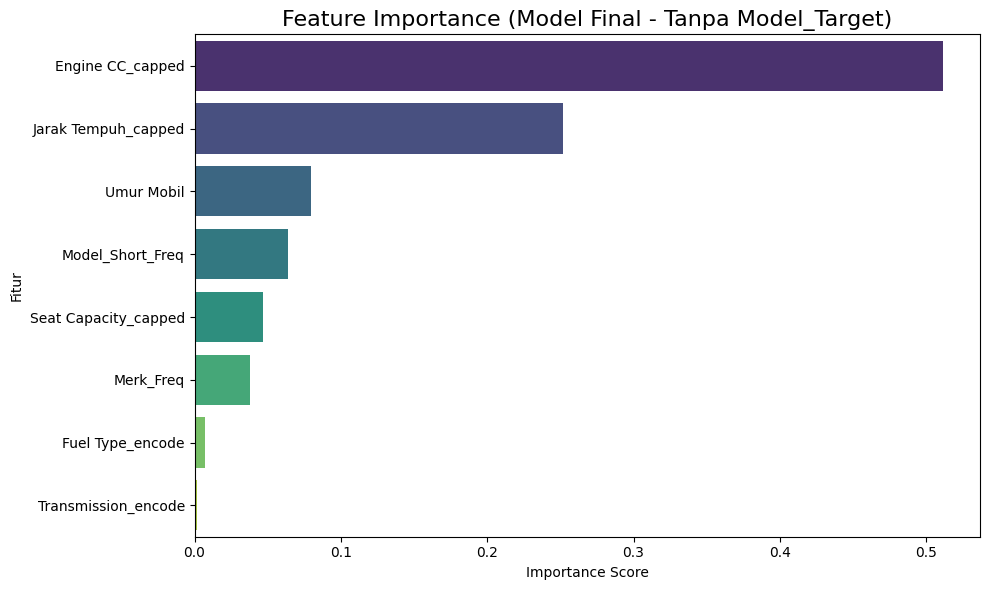

             Feature  Importance
    Engine CC_capped      0.5112
 Jarak Tempuh_capped      0.2518
          Umur Mobil      0.0793
    Model_Short_Freq      0.0642
Seat Capacity_capped      0.0470
           Merk_Freq      0.0379
    Fuel Type_encode      0.0072
 Transmission_encode      0.0014


In [ ]:
# Sel 11 (GANTI): Feature Importance (Perbaikan)

# Pastikan sel ini dijalankan SETELAH Sel 10

# Gunakan 'final_model' (model terbaik dari Sel 10)
importances = final_model.feature_importances_

feature_df = pd.DataFrame({
        # Gunakan variabel global_feature_names dari Sel 5
        'Feature': global_feature_names, 
        'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x="Importance", y="Feature", palette="viridis")
plt.title("Feature Importance (Model Final - Tanpa Model_Target)", fontsize=16)
plt.xlabel("Importance Score")
plt.ylabel("Fitur")
plt.tight_layout()
plt.savefig("feature_importance_fixed.png")
plt.show()

# Tampilkan juga dalam bentuk tabel
print(feature_df.to_string(index=False, float_format='{:,.4f}'.format))

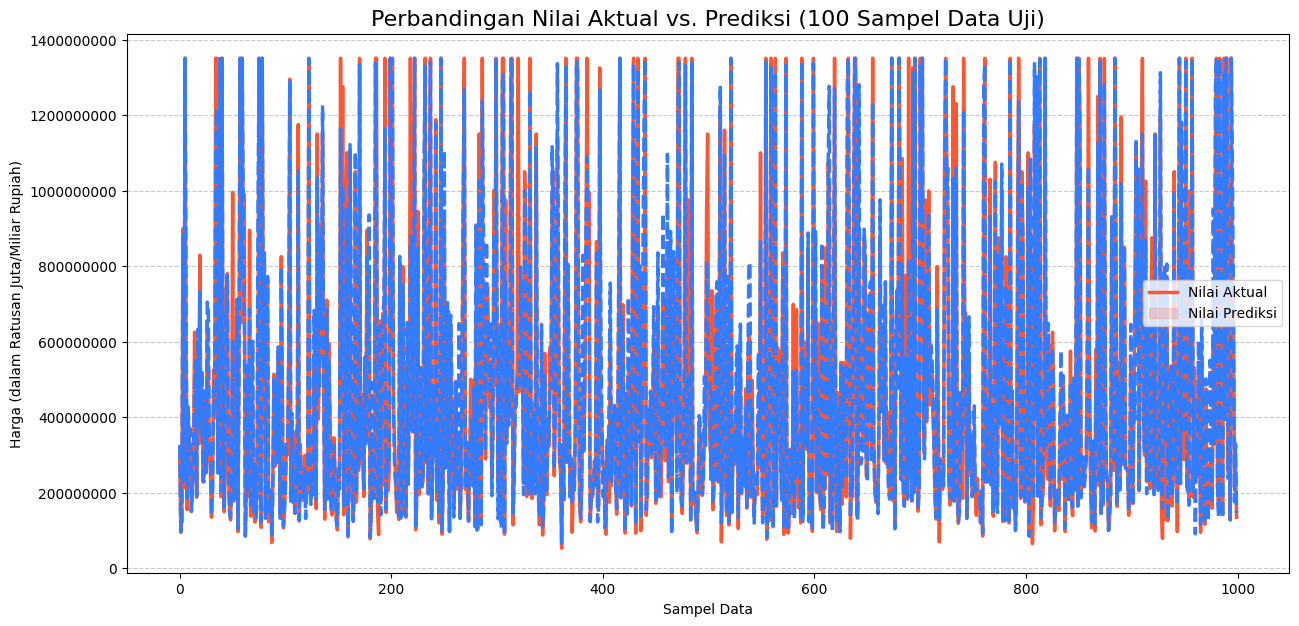

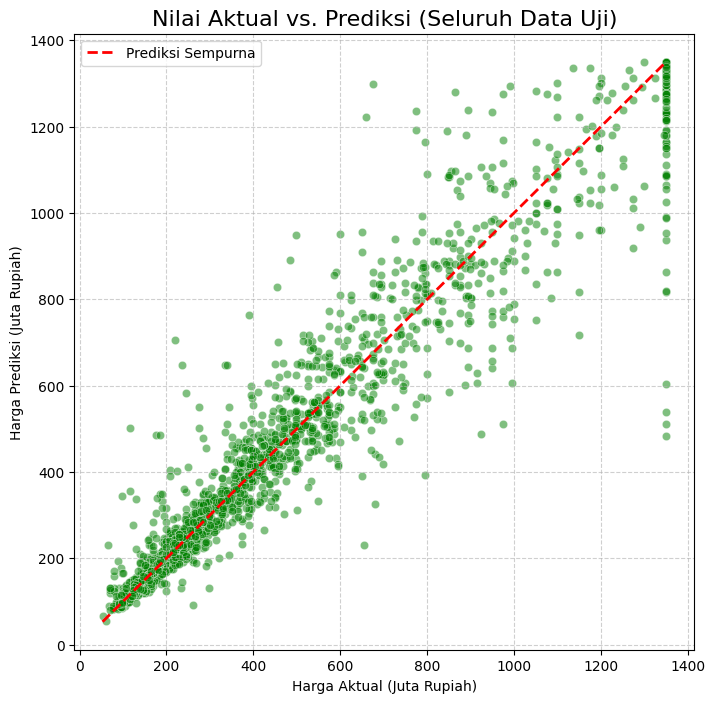

In [ ]:
# Sel 11: Membuat DataFrame Perbandingan dan Line Plot

# 1. Buat DataFrame untuk perbandingan
# Kita gunakan y_test.values untuk mereset index agar sesuai dengan y_pred_final (numpy array)
df_plot = pd.DataFrame({
    'Nilai Aktual': y_test.values,
    'Nilai Prediksi': y_pred_final
}).reset_index(drop=True)

# 2. Ambil sampel (misal 100 data pertama) agar plot mudah dibaca
df_plot_sample = df_plot.head(1000)

# 3. Buat plot
plt.figure(figsize=(15, 7))
sns.lineplot(data=df_plot_sample, linewidth=2.5, palette=['#FF5733', '#337BFF'])

plt.title('Perbandingan Nilai Aktual vs. Prediksi (100 Sampel Data Uji)', fontsize=16)
plt.xlabel('Sampel Data')
plt.ylabel('Harga (dalam Ratusan Juta/Miliar Rupiah)')
plt.ticklabel_format(style='plain', axis='y')
plt.legend(labels=['Nilai Aktual', 'Nilai Prediksi'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Sel 12: Membuat Scatter Plot (Aktual vs Prediksi)

plt.figure(figsize=(8, 8))

# Buat scatter plot
sns.scatterplot(x=y_test / 1_000_000, y=y_pred_final / 1_000_000, alpha=0.5, color='green')

# Buat garis 45 derajat (prediksi sempurna)
min_val = min(y_test.min(), y_pred_final.min()) / 1_000_000
max_val = max(y_test.max(), y_pred_final.max()) / 1_000_000
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediksi Sempurna')

plt.title('Nilai Aktual vs. Prediksi (Seluruh Data Uji)', fontsize=16)
plt.xlabel('Harga Aktual (Juta Rupiah)')
plt.ylabel('Harga Prediksi (Juta Rupiah)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.ticklabel_format(style='plain', axis='both')
plt.show()